# BrushCue Example: Rose Tint

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/rose_tint.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/rose-tint

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


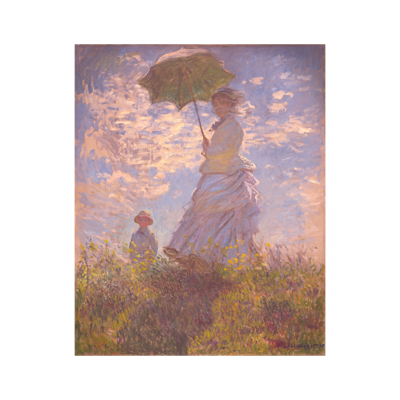

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
strength = 0.5
brightness_boost = (
    input_image.saturation_adjust(((0.5 * 0.3) + 1.0))
    .chroma_offset(bc.Vector2f.from_components(0.08, 0.05).scalar_multiply(0.5))
    .brightness_adjust((0.1 * strength))
)
bounds = brightness_boost.bounds()
rectangle_size = bc.Vector2i.from_components(
    bounds.width().round_to_int(), bounds.height().round_to_int()
).to_vector2f()
rectangle_center = rectangle_size.scalar_multiply(0.5)
graph = (
    bc.Composition.painter(
        bc.Painter.new().add_rectangle_with_render_style(
            bc.Point2f.from_components(rectangle_center.x(), rectangle_center.y()),
            rectangle_size,
            0.0,
            bc.RenderStyle.fill_only(
                bc.Fill.solid(
                    bc.ProfiledColor.from_rgba_srgb(
                        bc.RGBAColor.from_components(1.0, 0.7, 0.8, 1.0)
                    )
                )
            ),
            bc.Transform2.identity().to_list(),
        )
    )
    .linear_transform(
        1.0,
        0.0,
        0.0,
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        0.0,
        0.0,
        1.0,
        0.0,
        0.0,
        0.0,
        0.0,
        (strength * 0.2),
    )
    .blend_alpha(brightness_boost, bc.Transform2.identity())
    .vignette(
        bc.Vector2f.from_components(
            (input_image.bounds().width() / 2.0), (input_image.bounds().height() / 2.0)
        ),
        (input_image.bounds().width() / 2.0),
        (input_image.bounds().height() / 2.0),
        271.0,
        0.38,
    )
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
